In [17]:
import os
import time
import pandas as pd
import shutil
import io
from datetime import datetime
from PIL import Image
from IPython.display import display, Image as IPImage

# Google Generative AI components
import google.generativeai as genai
from google.generativeai import types

# --- CONFIGURATION ---
DATA_PATH = "words.csv"
KEY_FILE = "gemini_key.txt"
IMAGE_DIR = "icons"
OLD_IMAGE_DIR = os.path.join(IMAGE_DIR, "old_images")
SKIP_EXISTING = True 
RPM_LIMIT = 10        
SLEEP_TIME = 60 / RPM_LIMIT

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(OLD_IMAGE_DIR, exist_ok=True)

print("Setup updated. io and types imported.")

Setup updated. io and types imported.


In [18]:
with open(KEY_FILE, "r") as f:
    api_key = f.read().strip()

genai.configure(api_key=api_key)

# We use the specific image-generation model 
# (Note: Use the model name provided in your API console, usually 'imagen-3-fast' or 'gemini-3-flash-image')
model = genai.GenerativeModel('gemini-2.5-flash-image') 

print("API Client initialized.")

API Client initialized.


In [19]:
from PIL import Image, ImageDraw, ImageOps

def apply_app_icon_mask(filepath, radius=180):
    """
    Takes the black and white generation, keeps the center, 
    rounds the corners, and makes the exterior transparent.
    """
    img = Image.open(filepath).convert("RGBA")
    size = img.size
    
    # Create a high-quality mask for rounded corners
    mask = Image.new('L', size, 0)
    draw = ImageDraw.Draw(mask)
    
    # Draw a rounded rectangle (the 'App Icon' shape)
    # radius=180 gives a nice modern 'squircle' feel at 1024px
    draw.rounded_rectangle((0, 0, size[0], size[1]), radius=radius, fill=255)
    
    # Create the final image
    output = Image.new('RGBA', size, (0, 0, 0, 0))
    
    # Paste the original image onto the transparent canvas using the mask
    output.paste(img, (0, 0), mask)
    
    # Optimization: If you want 'smaller' files, we can resize here
    # output = output.resize((256, 256), Image.LANCZOS)
    
    output.save(filepath, "PNG")

print("Post-processing logic defined.")

Post-processing logic defined.


In [20]:
def process_image(word, category, skip_existing=True):
    filename = f"{category}_{word}.png"
    filepath = os.path.join(IMAGE_DIR, filename)
    
    # 1. Versioning Logic
    if os.path.exists(filepath):
        if skip_existing:
            return None
        else:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            old_filepath = os.path.join(OLD_IMAGE_DIR, f"{timestamp}_{filename}")
            shutil.move(filepath, old_filepath)

    # 2. Refined Prompt: Symbolic & Metaphorical
    # We move away from "figure" and toward "symbol" or "representation"
    style_base = "solid white silhouette, centered, pure black background, minimalist flat vector icon, no fine lines, high contrast"
    
    if category == "action":
        # We prompt for a symbol that *represents* the action
        prompt = (f"A {style_base} of a simple symbol or object that represents the action '{word}'. "
                  f"Avoid showing a person if an object or nature symbol (like a snowflake for freezing) is more iconic. "
                  "No text, no shading.")
    else:
        prompt = f"A {style_base} of the object '{word}'. No text, no shading."

    # 3. API Call
    try:
        response = model.generate_content(
            prompt,
            generation_config={"response_modalities": ["IMAGE"]}
        )
        
        for part in response.candidates[0].content.parts:
            if hasattr(part, 'inline_data') and part.inline_data.data:
                with open(filepath, "wb") as f:
                    f.write(part.inline_data.data)
                
                # 4. Apply the Rounded Corner/Transparency Mask
                apply_app_icon_mask(filepath)
                
                return filepath
    except Exception as e:
        print(f"API Error for {word}: {e}")
    
    return None

33
Starting Pilot Test...
Generating action icon for: humming


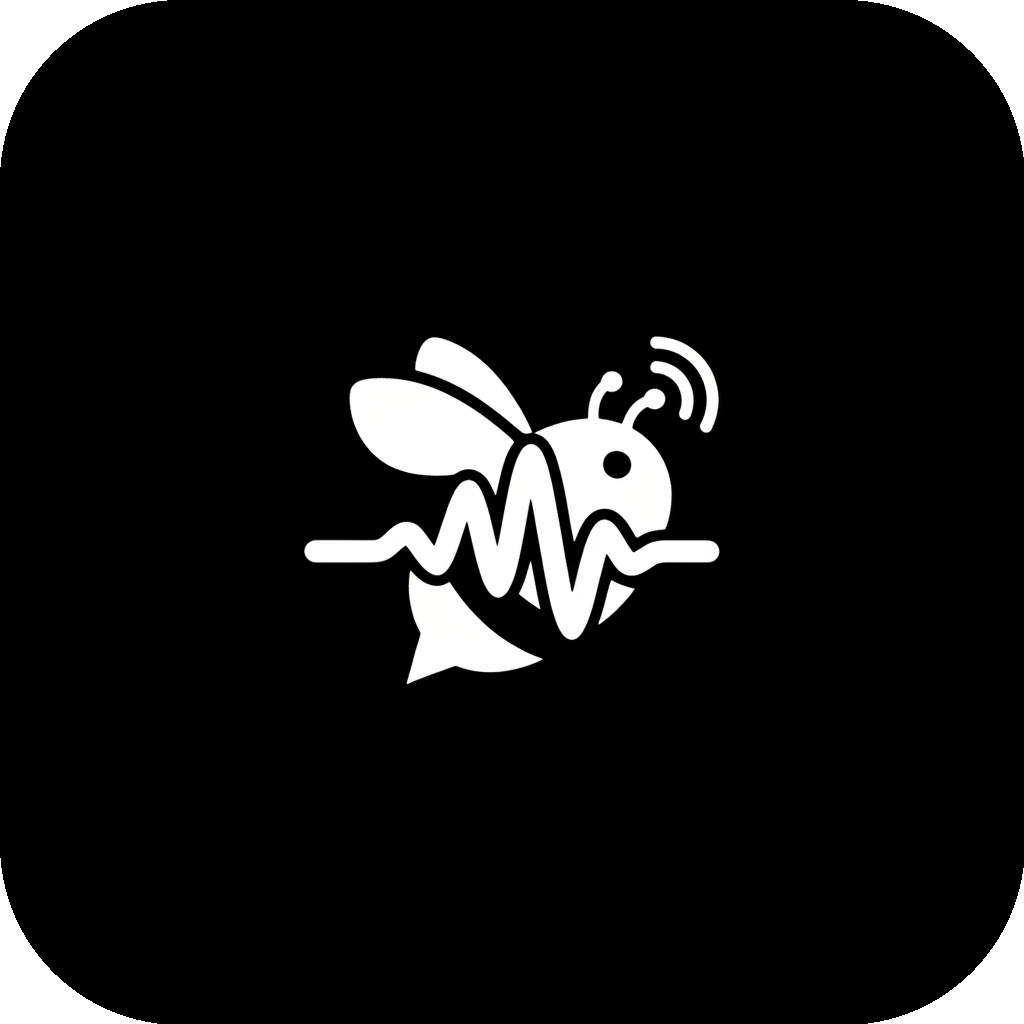

Generating object icon for: lantern


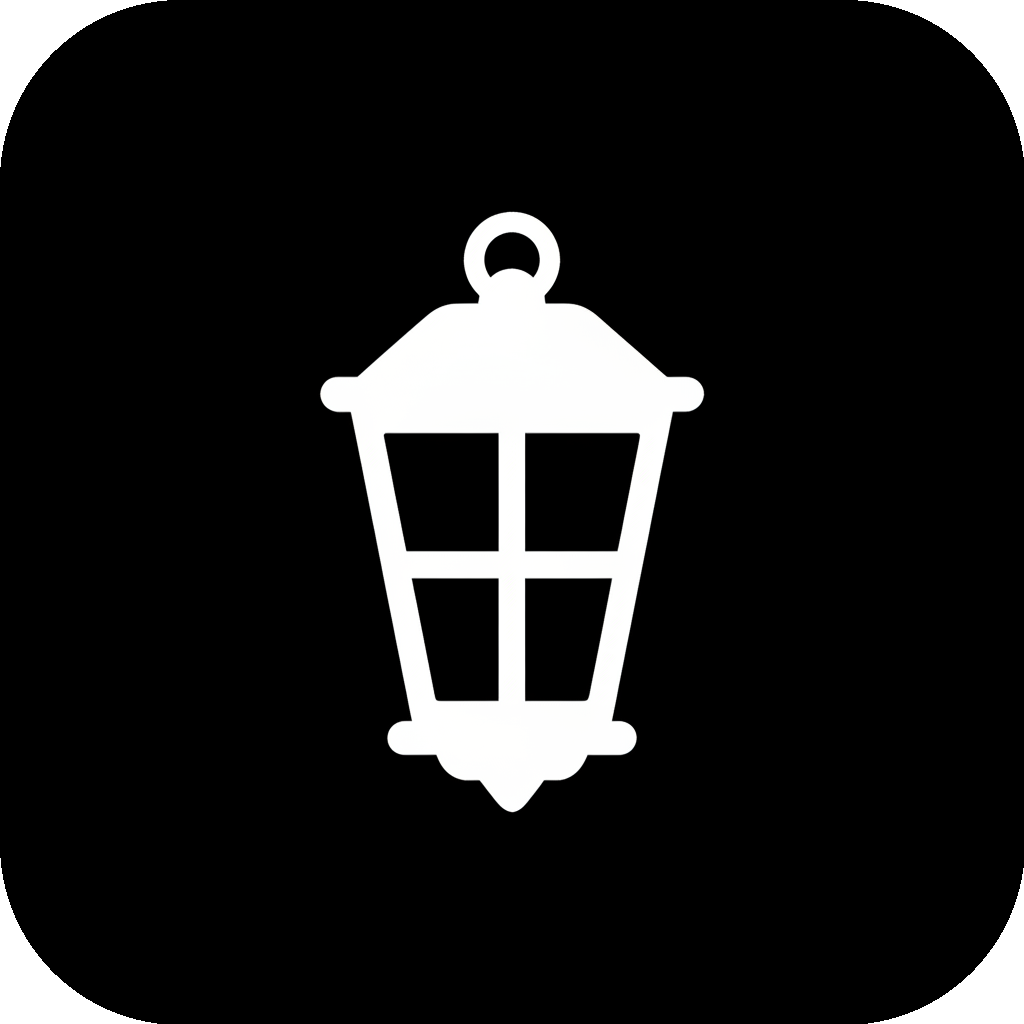

In [ ]:
# Load data
df = pd.read_csv(DATA_PATH)

# Selects 1 random row
test_rows = df.sample(n=1)

# Accesses and prints the index value
print(test_rows.index[0])

print("Starting Pilot Test...")
for index, row in test_rows.iterrows():
    for category in ['action', 'object']:
        word = row[category]
        print(f"Generating {category} icon for: {word}")
        
        # We set skip_existing=False for tests to ensure we see fresh results
        path = process_image(word, category, skip_existing=False)
        
        if path:
            display(IPImage(filename=path, width=150))
            time.sleep(SLEEP_TIME)

print("Pilot test complete.")

In [ ]:
print(f"Starting bulk run for {len(df)} pairs...")

for index, row in df.iterrows():
    for category in ['action', 'object']:
        word = row[category]
        
        # This will skip if SKIP_EXISTING is True and the file is there
        path = process_image(word, category, skip_existing=SKIP_EXISTING)
        
        if path:
            print(f"Generated: {path}")
            time.sleep(SLEEP_TIME)
        else:
            # If path is None, it was skipped
            pass

print("All images processed successfully.")

In [ ]:
import matplotlib.pyplot as plt

def show_random_usernames(n=3):
    samples = df.sample(n)
    
    for _, row in samples.iterrows():
        username = f"{row['action']}_{row['object']}".capitalize()
        
        fig, ax = plt.subplots(1, 2, figsize=(4, 2))
        
        action_img = Image.open(os.path.join(IMAGE_DIR, f"action_{row['action']}.png"))
        object_img = Image.open(os.path.join(IMAGE_DIR, f"object_{row['object']}.png"))
        
        ax[0].imshow(action_img, cmap='gray')
        ax[0].axis('off')
        ax[1].imshow(object_img, cmap='gray')
        ax[1].axis('off')
        
        plt.suptitle(f"User: {username}", fontsize=14, fontweight='bold')
        plt.show()

show_random_usernames(5)